# API Tutorial for OpenF1

In this Jupyter Notebook we will have a brief look into some of the different
analyses we can perform with the open-source API that provides real-time and
historical Formula 1 data, [OpenF1].

The API is really easy once you are a bit familiar with it. All the searches
can be done with a single command line and with access to internet. In case of
wanting to run the API locally or wanting to contribute on the project,
everyone is more than welcome to do so on the Github [repository].

During this tutorial we will get familiarized with how to obtain the data and
later on we will move on doing some analyses with every different dataset the
API provides.

## Getting started

In order to extract the data we must have some Python packages installed
in our system. The packages are:
- [Requests]
- [Json]

Once we have the packages installed we can already start looking into the data.
The API allows us to obtain many infomation regarding the driver, race,
position, weather, etc. All the data comes in Json format or .csv that can be
enabled with some minor changes. In this tutorial we will show how to work with
the json format as it is the standard use, however .csv can be also used.


To start we have to import the packages to obtain the data.
<!--- LINKS --->

[Json]: <https://docs.python.org/es/3/library/json.html>
[Requests]: <https://pypi.org/project/requests/#description>
[repository]: <https://github.com/br-g/openf1>
[OpenF1]: <https://openf1.org/#introduction>


In [ ]:
import requests
import json

Once we have the packages loaded we can start requesting the information to the
API.

### First steps

As a first aproach, we want to get the information about the driver Max
Verstappen. To do so, we will get the specific url to know about the drivers
information and later set the session_key attribute to latest (to be up to date).
We also have to let the API know about the driver number that he uses during
the year of competition that our data is (1 as he won the World Championship in
2023).

In [ ]:
url = "https://api.openf1.org/v1/drivers?driver_number=1&session_key=latest"

With the url stored we can now do a request on the API to get the information
with the module requests. What we are doing is accessing the website and asking
for all the information of the url. To know if the requests (Response 200)
has been successful, you can uncomment the `response.status_code` command.

In [ ]:
response = requests.get(url)
# response.status_code

If the requests has been successful we can then continue with getting the
contents of it with the json module. This one will ensure us that the data is in
the correct json format in case it has been wrongly formatted when obtaining
it.

In [ ]:
data = json.loads(response.content)

With this new data we can now take a first look of how it looks like.

In [ ]:
data

[{'session_key': 9662,
  'meeting_key': 1252,
  'broadcast_name': 'M VERSTAPPEN',
  'country_code': 'NED',
  'first_name': 'Max',
  'full_name': 'Max VERSTAPPEN',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/M/MAXVER01_Max_Verstappen/maxver01.png.transform/1col/image.png',
  'last_name': 'Verstappen',
  'driver_number': 1,
  'team_colour': '3671C6',
  'team_name': 'Red Bull Racing',
  'name_acronym': 'VER'}]

As it can be seen, the data is stored in the form of a diccionary and the
contents of it are session_key, meeting_key, broadcast_name, country_code,
first_name, full_name, headshot_url, last_name, driver_number, team_colour,
team_name and name_acronym. Each different key has a specific value.

In case we would like to know the information of another driver, such as
Fernando Alonso for example (driver number 14), we would have to change the
API url and ask for the request again as it follows:

In [ ]:
# Fernando Alonso driver information
url = "https://api.openf1.org/v1/drivers?driver_number=14&session_key=latest"
response = requests.get(url)
data = json.loads(response.content)
data

[{'session_key': 9662,
  'meeting_key': 1252,
  'broadcast_name': 'F ALONSO',
  'country_code': 'ESP',
  'first_name': 'Fernando',
  'full_name': 'Fernando ALONSO',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/F/FERALO01_Fernando_Alonso/feralo01.png.transform/1col/image.png',
  'last_name': 'Alonso',
  'driver_number': 14,
  'team_colour': '229971',
  'team_name': 'Aston Martin',
  'name_acronym': 'ALO'}]

It is important to know that you need to know the driver number in order to
obtain the data about it. If it is not the case, you can also obtain the data
about all the drivers at once with the following commands:

In [ ]:
# All drivers information
url = "https://api.openf1.org/v1/drivers?session_key=latest"
response = requests.get(url)
data = json.loads(response.content)
data

[{'session_key': 9998,
  'meeting_key': 1255,
  'broadcast_name': 'M VERSTAPPEN',
  'country_code': 'NED',
  'first_name': 'Max',
  'full_name': 'Max VERSTAPPEN',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/M/MAXVER01_Max_Verstappen/maxver01.png.transform/1col/image.png',
  'last_name': 'Verstappen',
  'driver_number': 1,
  'team_colour': '3671C6',
  'team_name': 'Red Bull Racing',
  'name_acronym': 'VER'},
 {'session_key': 9998,
  'meeting_key': 1255,
  'broadcast_name': 'L NORRIS',
  'country_code': 'GBR',
  'first_name': 'Lando',
  'full_name': 'Lando NORRIS',
  'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/L/LANNOR01_Lando_Norris/lannor01.png.transform/1col/image.png',
  'last_name': 'Norris',
  'driver_number': 4,
  'team_colour': 'FF8000',
  'team_name': 'McLaren',
  'name_acronym': 'NOR'},
 {'session_key': 9998,
  'meeting_key': 1255,
  'broadcast_name': 'G BOR

In this case that we have the data about all the drivers, in case we would only
want to know the data about Max Verstappen we would have to do as follows:

In [ ]:
# Iterate over all the drivers
for i in range(len(data)):
    if data[i]["name_acronym"] == "VER":
        display(data[i])

{'session_key': 9998,
 'meeting_key': 1255,
 'broadcast_name': 'M VERSTAPPEN',
 'country_code': 'NED',
 'first_name': 'Max',
 'full_name': 'Max VERSTAPPEN',
 'headshot_url': 'https://media.formula1.com/d_driver_fallback_image.png/content/dam/fom-website/drivers/M/MAXVER01_Max_Verstappen/maxver01.png.transform/1col/image.png',
 'last_name': 'Verstappen',
 'driver_number': 1,
 'team_colour': '3671C6',
 'team_name': 'Red Bull Racing',
 'name_acronym': 'VER'}

Here we iterated over all the drivers on the data and checked for the
name_acronym in order to obtain the data about Max. Once we got that, we then
know in which position the data is and we can show it on screen.

Now that we have already showed how to obtain the data you can take a look at
the other different types of information that the API provides and get
familiarized with how the format of each data comes.

## Car data

With the car data we can do some simple analyses. The first ones that comes to
mind is, knowing that we get the information about the speed (velocity in
km/h), which has been the maximum speed about all the drivers during the
race, qualy or even the free practice.

To do this, we will have to first get the url about the cars information from
all the drivers and later on iterate on that data.

In [ ]:
# All car information
url = "https://api.openf1.org/v1/car_data?session_key=9166&speed>=300"
response = requests.get(url)
car = json.loads(response.content)
car

[{'driver_number': 1,
  'rpm': 10665,
  'speed': 300,
  'n_gear': 8,
  'throttle': 100,
  'brake': 0,
  'drs': 12,
  'date': '2023-09-22T02:31:55.512000+00:00',
  'session_key': 9166,
  'meeting_key': 1220},
 {'driver_number': 1,
  'rpm': 10729,
  'speed': 304,
  'n_gear': 8,
  'throttle': 100,
  'brake': 0,
  'drs': 12,
  'date': '2023-09-22T02:31:55.792000+00:00',
  'session_key': 9166,
  'meeting_key': 1220},
 {'driver_number': 1,
  'rpm': 10842,
  'speed': 306,
  'n_gear': 8,
  'throttle': 100,
  'brake': 0,
  'drs': 12,
  'date': '2023-09-22T02:31:55.992000+00:00',
  'session_key': 9166,
  'meeting_key': 1220},
 {'driver_number': 1,
  'rpm': 10868,
  'speed': 307,
  'n_gear': 8,
  'throttle': 100,
  'brake': 0,
  'drs': 12,
  'date': '2023-09-22T02:31:56.192000+00:00',
  'session_key': 9166,
  'meeting_key': 1220},
 {'driver_number': 1,
  'rpm': 10915,
  'speed': 309,
  'n_gear': 8,
  'throttle': 100,
  'brake': 0,
  'drs': 12,
  'date': '2023-09-22T02:31:56.552000+00:00',
  'sess

Once we have the data we can iterate on it and obtain the maximum speed for
each driver.

In [ ]:
max_speed = dict()

for i in range(len(car)):
    if car[i]["driver_number"] not in max_speed:
        max_speed[car[i]["driver_number"]] = car[i]["speed"]
    else:
        if car[i]["speed"] > max_speed[car[i]["driver_number"]]:
            max_speed[car[i]["driver_number"]] = car[i]["speed"]

max_speed

{1: 331,
 18: 323,
 63: 322,
 11: 328,
 24: 322,
 27: 321,
 20: 322,
 77: 321,
 40: 323,
 16: 325,
 55: 329,
 31: 324,
 81: 326,
 44: 320,
 4: 326,
 10: 328,
 2: 329,
 14: 323,
 23: 331,
 22: 330}

In order to obtain the maximum speed of each driver during the race we start having some serious iterations starting by creating a diccionary and then iterating over all the data and checking for each driver if the speed they have stored in the diccionary is smaller than the one they got afterwards.

Now that we have this diccionary we can plot the maximum speeds of each driver. To do so, we will use the [matplotlib] module. With it we are able to plot the driver number and its corresponding maximum speed. This is a really simple plot but helps us to show that we can archieve with the data obtained from the API.

[matplotlib]: <https://matplotlib.org/>

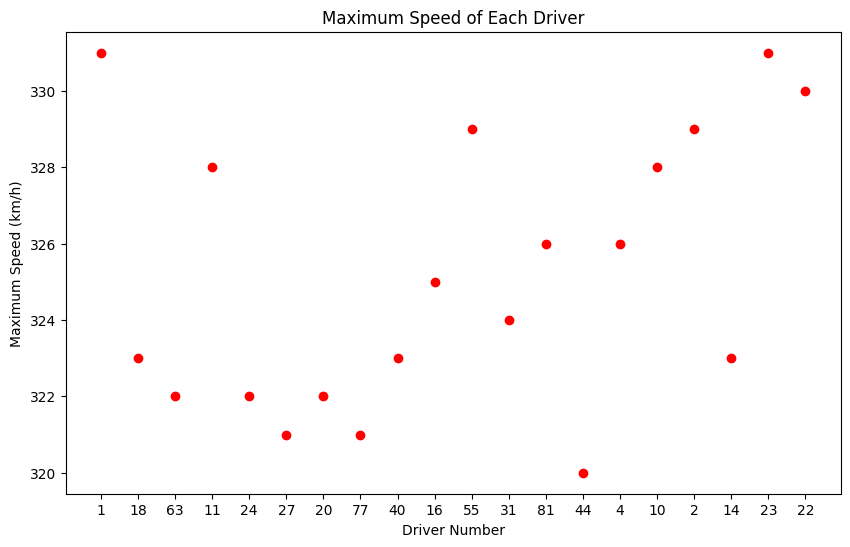

In [ ]:
# Libraries
import matplotlib.pyplot as plt

# Data modifications
driver_numbers = list(max_speed.keys())
speeds = list(max_speed.values())
x_positions = range(len(driver_numbers))

# Plot features
plt.figure(figsize=(10, 6))
plt.scatter(x_positions, speeds, color="red")
plt.xlabel("Driver Number")
plt.ylabel("Maximum Speed (km/h)")
plt.title("Maximum Speed of Each Driver")
plt.xticks(x_positions, driver_numbers)

plt.show()

If we would like to make the plot much more informative and interesting we could use other datasets that the API provides and for example replace the driver numbers for the name_acronyms and instead of having the dots be red, we could color them by the team color.

## Drivers

With this API method we are able to get all the information regarding the drivers as we looked on the getting started section.

As we have already seen a bit how the structure of this method goes, we will reuse the data from the Car dataset and create a better plot with the maximum speeds. To do so, we create 3 new diccionaries storing the team_color of the driver, the team of the driver and the number of the driver with its acronym.

In [ ]:
# Drivers information
url = "https://api.openf1.org/v1/drivers?session_key=9166"
response = requests.get(url)
drivers = json.loads(response.content)

driver_number = dict()
driver_color = dict()
driver_team = dict()

for i in range(len(drivers)):
    driver_number[drivers[i]["name_acronym"]] = drivers[i]["driver_number"]
    driver_color[drivers[i]["name_acronym"]] = drivers[i]["team_colour"]
    driver_team[drivers[i]["name_acronym"]] = drivers[i]["team_name"]

Now that we have all the data necessary in order to improve the previous plot we proceed with its visualization.

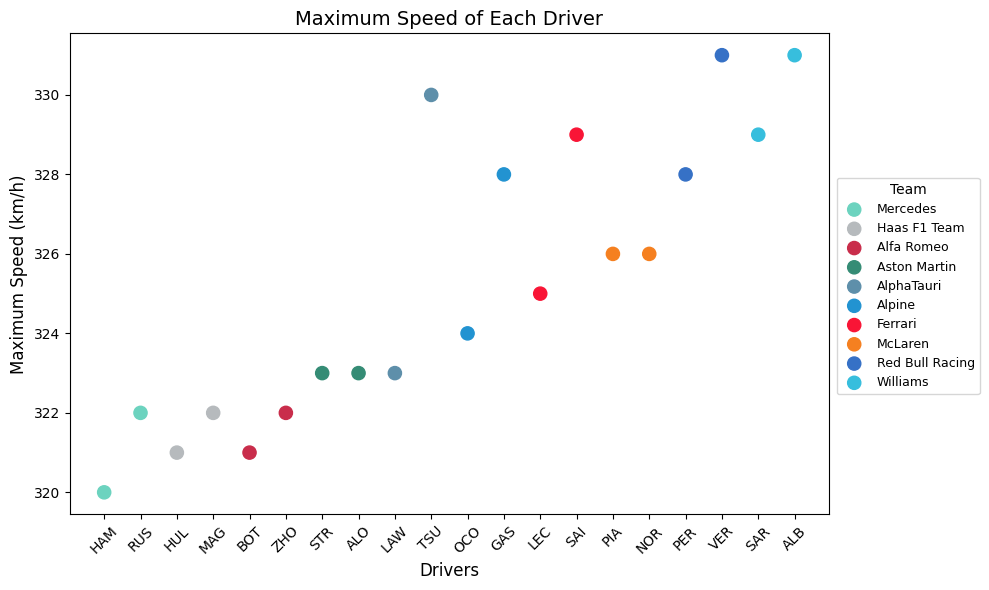

In [ ]:
# Libraries
import matplotlib.pyplot as plt


# Reverse the `driver_number` dictionary to map driver numbers to acronyms
number_to_acronym = {v: k for k, v in driver_number.items()}

# Prepare data for the plot
driver_acronyms = [number_to_acronym[num] for num in max_speed.keys()]
speeds = list(max_speed.values())
teams = [driver_team[number_to_acronym[num]] for num in max_speed.keys()]
colors = [driver_color[number_to_acronym[num]] for num in max_speed.keys()]
color_hex = ['#{0}'.format(color) for color in colors]

# Combine data for sorting
data = list(zip(speeds, driver_acronyms, teams, color_hex))
# Sort data by speed (ascending order)
data_sorted = sorted(data, key=lambda x: x[0])
# Unpack sorted data
speeds, driver_acronyms, teams, color_hex = zip(*data_sorted)

# Create a mapping of team to drivers
team_data = {}
for team, speed, acronym, color in zip(teams, speeds, driver_acronyms, color_hex):
    if team not in team_data:
        team_data[team] = {"speeds": [], "acronyms": [], "colors": []}
    team_data[team]["speeds"].append(speed)
    team_data[team]["acronyms"].append(acronym)
    team_data[team]["colors"].append(color)

# Plot features
plt.figure(figsize=(10, 6))
x_positions = []
x_labels = []
current_x = 0

for team, data in team_data.items():
    x_positions.extend(range(current_x, current_x + len(data["speeds"])))
    x_labels.extend(data["acronyms"])
    plt.scatter( range(current_x, current_x + len(data["speeds"])),
        data["speeds"],
        color=data["colors"],
        label=team,
        s=90,
    )
    current_x += len(data["speeds"])

plt.xlabel("Drivers", fontsize=12)
plt.ylabel("Maximum Speed (km/h)", fontsize=12)
plt.title("Maximum Speed of Each Driver", fontsize=14)
plt.xticks(x_positions, x_labels, rotation=45, fontsize=10)
plt.legend(title="Team", loc="upper left", bbox_to_anchor=(1.01, 0.7),
    fontsize=9, borderaxespad=0,)
plt.tight_layout()

plt.show()


As seen, this plot is clearly much better than the previous one. This one shows the name acronym of each driver, the color of the team they are racing with, it is also sorted from smallest top speed to biggest and has a legend saying which color has each team. What does this mean? Combining diferent API methods will facilitate you whenever wanting to do some analysis with the data. If you felt overwhelmed by the previous chunk of code do not worry. There are simpler aproaches to do different plots and once you are a bit familiarized with how Matplotlib works your life will be much easier. In case you want to learn more about how the package works, here are a few [examples].

[examples]: <https://matplotlib.org/stable/gallery/index.html>

## Intervals

Intervals are interesting but do not provide a lot of information in case you want to plot or extract some valuable information. We must keep in mind that the date is in ISO 8601 format so it must be transformed in order to propperly obtain the minutes or seconds.

Here we represent the distance in seconds between Pierre Gasly and the leader of the race.

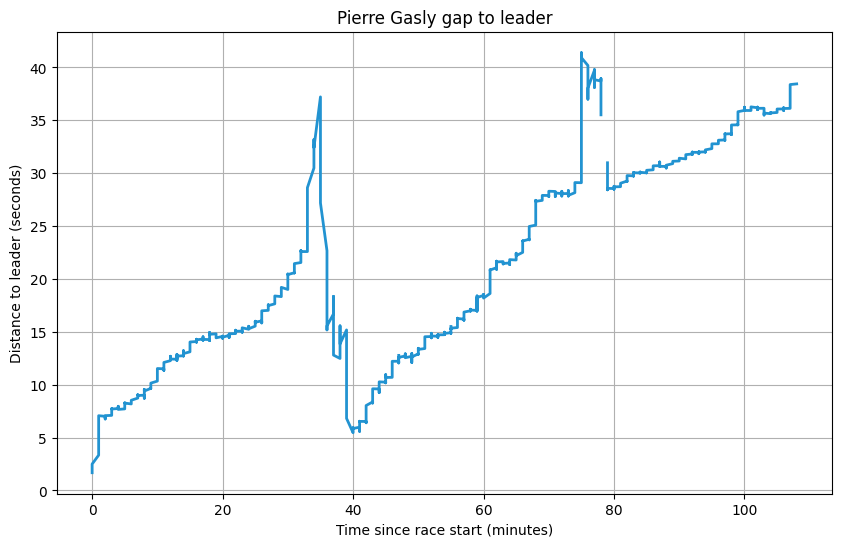

In [ ]:
# Libraries
import requests
import json
import matplotlib.pyplot as plt
from os import times
from datetime import datetime

# Intervals information
url = "https://api.openf1.org/v1/intervals?session_key=9165&driver_number=10"
response = requests.get(url)
data = json.loads(response.content)

# Get the color for driver 10
color = "#{0}".format(driver_color["GAS"])

# Extract gap to leader
gap = [data[i]["gap_to_leader"] for i in range(len(data))]
# Time transformations
time = [data[i]["date"] for i in range(len(data))]
time = [datetime.fromisoformat(t) for t in time]
time_in_minutes = [t.hour * 60 + t.minute for t in time]
start_time = time_in_minutes[0]
time_in_minutes = [t - start_time for t in time_in_minutes]


# Plot features
plt.figure(figsize=(10, 6))
plt.plot(time_in_minutes, gap, linestyle="solid", linewidth=2, color=color)
plt.xlabel("Time since race start (minutes)")
plt.ylabel("Distance to leader (seconds)")
plt.title("Pierre Gasly gap to leader")
plt.grid(True)

plt.show()


At the same time we can plot more than only one driver distance, for example we can compare the distance to the leader of Pierre, Stroll and Lando and see who was closest to the leader.

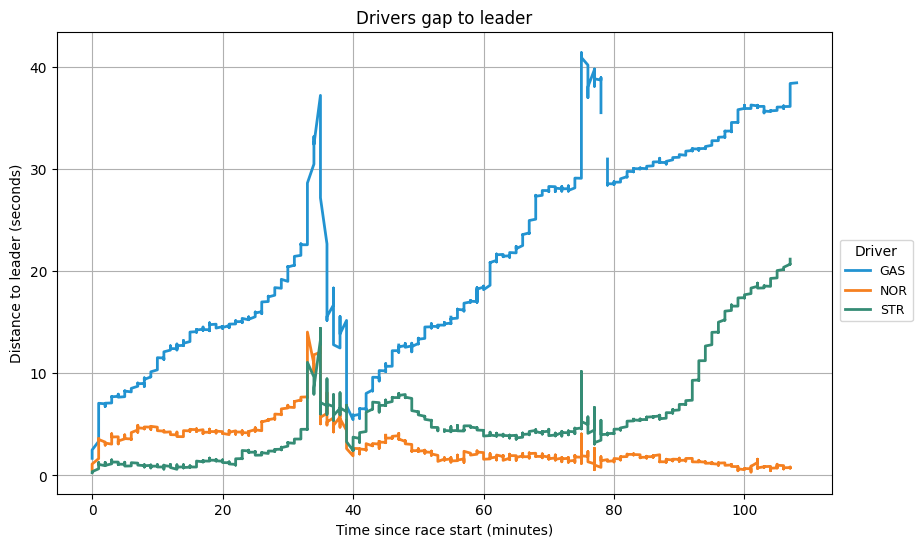

In [ ]:
# Intervals information
url = "https://api.openf1.org/v1/intervals?session_key=9165&driver_number=10"
response = requests.get(url)
data_g = json.loads(response.content)
url = "https://api.openf1.org/v1/intervals?session_key=9165&driver_number=4"
response = requests.get(url)
data_l = json.loads(response.content)
url = "https://api.openf1.org/v1/intervals?session_key=9165&driver_number=16"
response = requests.get(url)
data_s = json.loads(response.content)

# Get the color for drivers
color_g = "#{0}".format(driver_color["GAS"])
color_l = "#{0}".format(driver_color["NOR"])
color_s = "#{0}".format(driver_color["STR"])

# Extract gap to leader
gap_g = [data_g[i]["gap_to_leader"] for i in range(len(data_g))]
gap_l = [data_l[i]["gap_to_leader"] for i in range(len(data_l))]
gap_s = [data_s[i]["gap_to_leader"] for i in range(len(data_s))]

# Time transformations
time_g = [data_g[i]["date"] for i in range(len(data_g))]
time_g = [datetime.fromisoformat(t) for t in time_g]
time_in_minutes_g = [t.hour * 60 + t.minute for t in time_g]
start_time_g = time_in_minutes_g[0]
time_in_minutes_g = [t - start_time_g for t in time_in_minutes_g]
time_l = [data_l[i]["date"] for i in range(len(data_l))]
time_l = [datetime.fromisoformat(t) for t in time_l]
time_in_minutes_l = [t.hour * 60 + t.minute for t in time_l]
start_time_l = time_in_minutes_l[0]
time_in_minutes_l = [t - start_time_l for t in time_in_minutes_l]
time_s = [data_s[i]["date"] for i in range(len(data_s))]
time_s = [datetime.fromisoformat(t) for t in time_s]
time_in_minutes_s = [t.hour * 60 + t.minute for t in time_s]
start_time_s = time_in_minutes_s[0]
time_in_minutes_s = [t - start_time_s for t in time_in_minutes_s]

# Plot features
plt.figure(figsize=(10, 6))
plt.plot(time_in_minutes_g, gap_g, linestyle="solid", linewidth=2, color=color_g, label="GAS")
plt.plot(time_in_minutes_l, gap_l, linestyle="solid", linewidth=2, color=color_l, label="NOR")
plt.plot(time_in_minutes_s, gap_s, linestyle="solid", linewidth=2, color=color_s, label="STR")
plt.xlabel("Time since race start (minutes)")
plt.ylabel("Distance to leader (seconds)")
plt.title("Drivers gap to leader")
plt.legend(title="Driver", loc="upper left", bbox_to_anchor=(1.01, 0.55),
    fontsize=9, borderaxespad=0,)
plt.grid(True)

plt.show()

With this plot we can extract some conclusions such as the difference in rithm by the teams as Alpine in 2023 had a slow car and we can see it with the distance to the leader in comparison with McLaren and Aston Martin pace during the race. There are also some clear high peaks in the case of Pierre, two times
during the race. This is due to the pit-stops as Alpine decided to pit him
before the leader (increasing the time distance) and afterwards the leader pitted and therefore this gap with the leader was decreased.


## Laps

The laps method has a lot of different variables that we can look at. In this case we will focus on the lap duration of each driver. By doing so, what we can
see is if the driver has degradation or not during the race.

First we will take a look on how to plot the data of one driver and later we will try to do it for all the drivers.

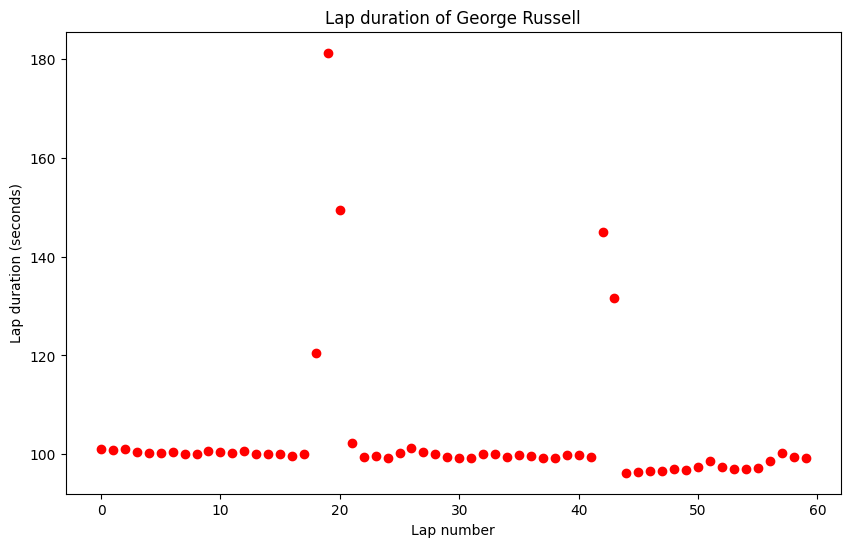

In [ ]:
# Laps information
url = "https://api.openf1.org/v1/laps?session_key=9165&driver_number=63"
request = requests.get(url)
data = json.loads(request.content)
lap_duration = [data[i]["lap_duration"] for i in range(1, len(data)-1)]

# Plot features
plt.figure(figsize=(10, 6))
plt.scatter(range(len(lap_duration)), lap_duration, color="red")
plt.xlabel("Lap number")
plt.ylabel("Lap duration (seconds)")
plt.title("Lap duration of George Russell")
plt.show()

In [ ]:
# Lap times for all drivers
driver_lap_times = {}

url = "https://api.openf1.org/v1/laps?session_key=9165&is_pit_out_lap=false&lap_duration<=108"
response = requests.get(url)
data = json.loads(response.content)

for number in driver_number.values():
  driver_lap_times[number] = []
  for lap in range(len(data)):
    if data[lap]["driver_number"] == number:
      if data[lap]["lap_duration"] != None:
        driver_lap_times[number].append(data[lap]["lap_duration"])

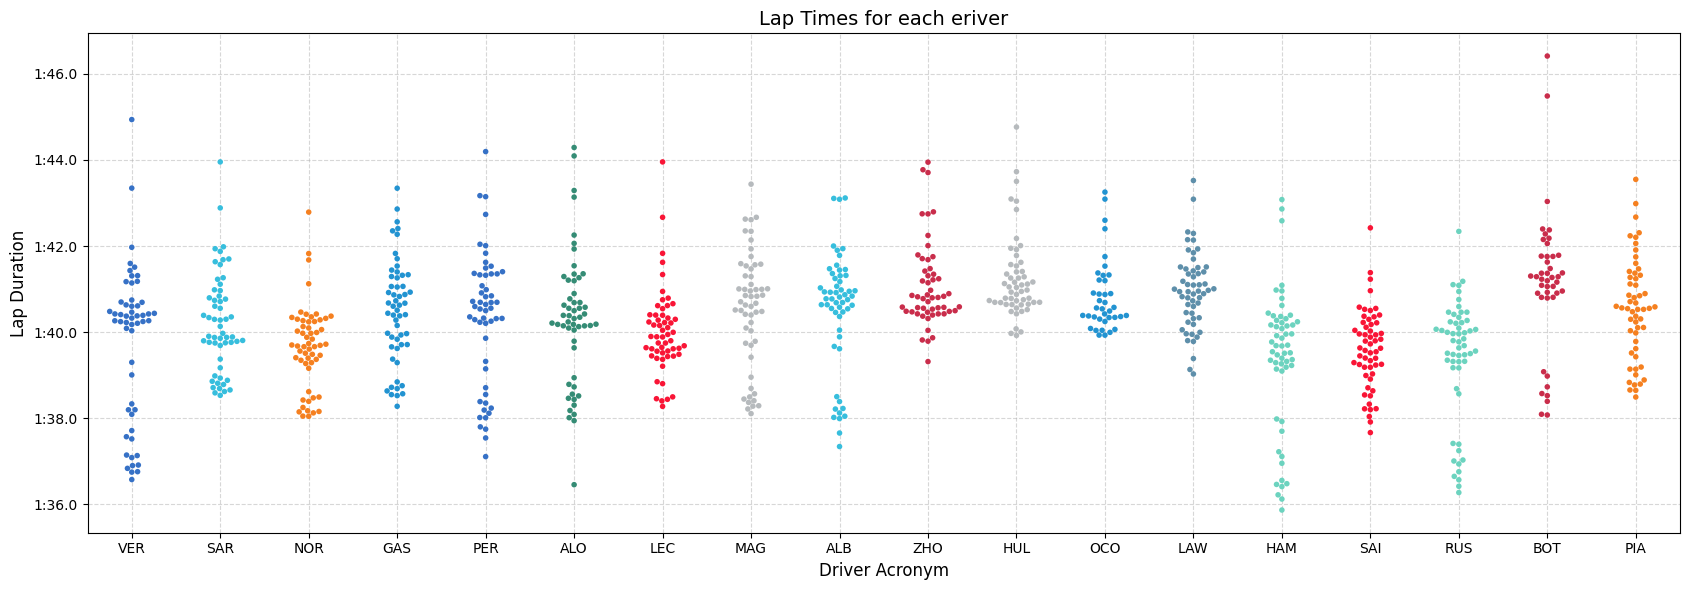

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
data = []

for driver_num, lap_times in driver_lap_times.items():
    acronym = number_to_acronym[driver_num]  # Convert number to acronym
    for lap_time in lap_times:
        data.append({
            "Driver": acronym,
            "Lap Time": lap_time
        })

df = pd.DataFrame(data)

# Create palette using acronyms (as in your driver_color dict)
acronym_to_color = {acronym: f"#{color}" for acronym, color in driver_color.items()}


from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(17, 6))
sns.swarmplot(data=df, x="Driver", y="Lap Time", hue="Driver", palette=acronym_to_color, size=4)
plt.xlabel("Driver Acronym", fontsize=12)
plt.ylabel("Lap Duration", fontsize=12)
plt.title("Lap Times for each eriver", fontsize=14)
plt.xticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Format Y-axis to show minutes:seconds
def seconds_to_minutes(x, pos):
    minutes = int(x) // 60
    seconds = x % 60
    return f"{minutes}:{seconds:04.1f}"

plt.gca().yaxis.set_major_formatter(FuncFormatter(seconds_to_minutes))

plt.tight_layout()
plt.show()


As it can be seen the plot shows all the lap times during the race. This time we did not sort them by teams but we showed its team color for each driver. We can see that there are laps were the duration is much bigger in comparison with the others. This is most likely due to yellow flags, safety cars or laps when the driver has pitted. We can be able to also know this information if we use other methods the API provides.


## Location

The location method provides the aproximate position of the cars at a sample rate of about 3.7 Hz. This method is really interesting as it is necessary in case you want to do a real-time live timing of the cars position during a live session. However, on our case, as we are not live we will only take a look on what we can do.

The data provides the date, x, y, z coordinates and also the driver_number along with the meeting and session key. With this we could for example plot the layout of the circuit the driver is racing.

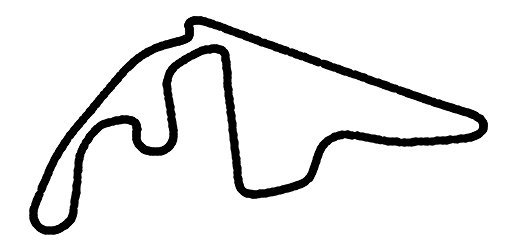

In [ ]:
# Location information
url = "https://api.openf1.org/v1/location?session_key=latest&driver_number=81"
response = requests.get(url)
data = json.loads(response.content)
data

# Data modification
from datetime import datetime
x_coords = []
y_coords = []

for i in range(len(data)):
  if datetime.fromisoformat(data[i]["date"]) >= datetime.fromisoformat("2024-12-08T13:12:19.078000+00:00"):
    x_coords.append(data[i]["x"])
    y_coords.append(data[i]["y"])
  if datetime.fromisoformat(data[i]["date"]) >=datetime.fromisoformat("2024-12-08T13:21:15.164000+00:00") :
    break

# Plot features
plt.scatter(y_coords, [-x for x in x_coords], color='black', marker='o', s=20)
plt.gca().set_aspect('equal', adjustable='box')
plt.axis("off")
plt.show()

Here we can see the layout of the latest circuit, the Yas Marina Circuit. It is a simple representation and we can make it look a bit fancier.

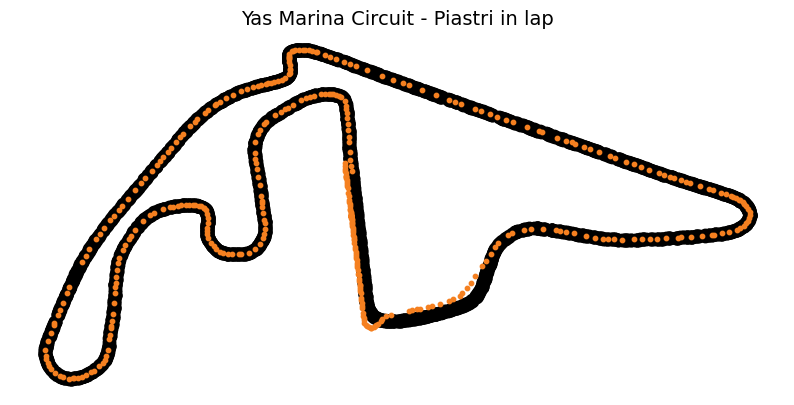

In [ ]:
# Data modification
x_coords_pit = []
y_coords_pit = []

for i in range(len(data)):
  if datetime.fromisoformat(data[i]["date"]) >= datetime.fromisoformat("2024-12-08T13:10:28.276000+00:00"):
    x_coords_pit.append(data[i]["x"])
    y_coords_pit.append(data[i]["y"])
  if datetime.fromisoformat(data[i]["date"]) >=datetime.fromisoformat("2024-12-08T13:12:19.078000+00:00") :
    break


# Plot features
plt.figure(figsize=(10, 10), facecolor="white")
plt.scatter(y_coords, [-x for x in x_coords], color="black", marker="o", s=80)
plt.scatter(y_coords_pit, [-x for x in x_coords_pit],color="#F58020", marker="o", s=10)
plt.gca().set_aspect("equal", adjustable="box")
plt.axis("off")
plt.title("Yas Marina Circuit - Piastri in-lap", fontsize=14)
plt.show()

This is a more informative plot and we are getting the location of Piastri during the in lap to pit. As it can be seen the location is not tracked every meter and therefore we have areas where there is no information about the location.

## Meetings

This API method only provides information about meetings. This ones refer to a Grand Prix or testing weekend and usually includes multiple sessions (practice, qualifying, race, ...).

This method provides information about the name of the circuits, country, timezone, year, etc. With this method we could extract all the meetings of the 2024 season and know their difference in ours to between the local time at the location of the event and Greenwich Mean Time (GMT).

In [ ]:
# Libraries
import pandas as pd

# Meetings information
url = "https://api.openf1.org/v1/meetings?year=2024"
response = requests.get(url)
data = json.loads(response.content)

# Data transformation
circuit = []
timezone = []

for i in range(len(data)):
  circuit.append(data[i]["meeting_official_name"])
  offset = int(data[i]["gmt_offset"].split(":")[0])
  timezone.append(f"+{offset}h" if offset > 0 else f"{offset}h")

# Pandas modification
df = pd.DataFrame({"Circuit": circuit, "GMT offset": timezone})
df

,Circuit,GMT offset
0,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2024,+3h
1,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2024,+3h
2,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2024,+11h
3,FORMULA 1 MSC CRUISES JAPANESE GRAND PRIX 2024,+9h
4,FORMULA 1 LENOVO CHINESE GRAND PRIX 2024,+8h
5,FORMULA 1 CRYPTO.COM MIAMI GRAND PRIX 2024,-4h
6,FORMULA 1 MSC CRUISES GRAN PREMIO DEL MADE IN ...,+2h
7,FORMULA 1 GRAND PRIX DE MONACO 2024,+2h
8,FORMULA 1 AWS GRAND PRIX DU CANADA 2024,-4h
9,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2024,+2h


This is a useful table were we are getting the name of the Grand Prix along with the hours difference. We can take this a step ahead and plot where the Grand Prix took place in a worldwide map with the ploty package. This is a simple way to know where the F1 travels to and maybe who knows, to use it for speculation of future new racetracks?



In [ ]:
# Import library
import plotly.express as px

# Data preparation
meeting_code = []
for meeting in range(len(data)):
    meeting_code.append(data[meeting]["meeting_code"])

# Plot features
fig = px.choropleth(locations = meeting_code ,locationmode='ISO-3' ,scope="world", projection="equirectangular")
fig.show()

## Pit

This method of the API is as simple as it sounds, it provides information about the cars that are going through the pit lane. We can obtain the pit_duration, lap_number, the specific time during the race and as always the session and meeting key. With the pit stop we can plot the already mostly knwown for everyone, the pit duration of each driver during a race.

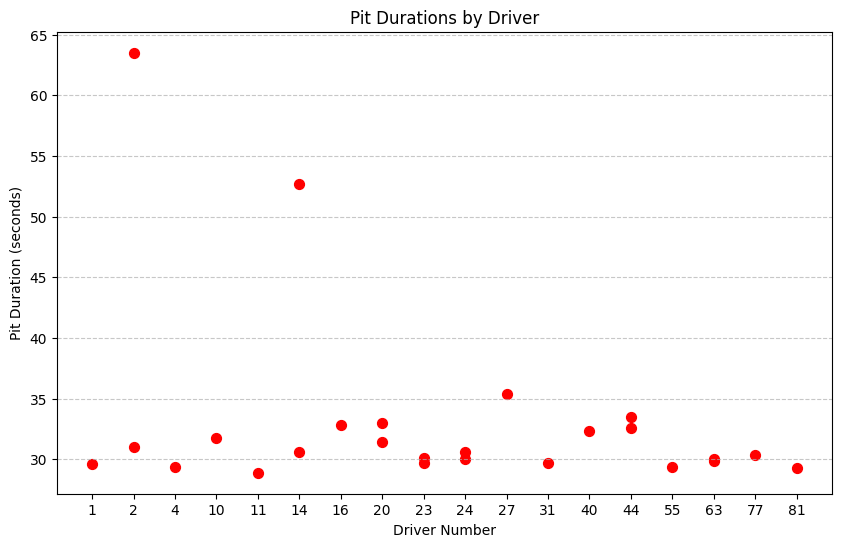

In [ ]:
# Pit information
url = "https://api.openf1.org/v1/pit?session_key=9165"
response = requests.get(url)
data = json.loads(response.content)

# Data preparation
times = []
drivers = []
for i in range(len(data)):
  times.append(data[i]["pit_duration"])
  drivers.append(data[i]["driver_number"])
unique_drivers = sorted(set(drivers))
driver_positions = {driver: i for i, driver in enumerate(unique_drivers)}
x_positions = [driver_positions[d] for d in drivers]

# Plot features
plt.figure(figsize=(10, 6))
plt.scatter(x_positions, times, s=50, color="red")
plt.xticks(range(len(unique_drivers)), labels=unique_drivers)
plt.xlabel('Driver Number')
plt.ylabel('Pit Duration (seconds)')
plt.title('Pit Durations by Driver')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

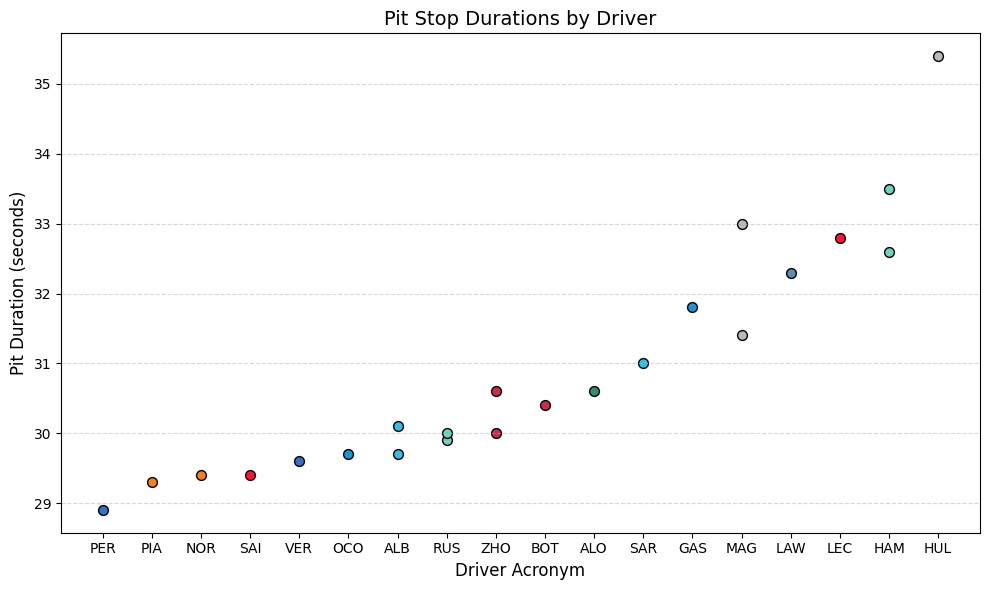

In [ ]:
import requests
import json
import matplotlib.pyplot as plt
import pandas as pd

# Pit information
url = "https://api.openf1.org/v1/pit?session_key=9165&pit_duration<40"
response = requests.get(url)
data = json.loads(response.content)

# Prepare pit stop data
pits = []
for entry in data:
    driver_num = entry["driver_number"]
    acronym = number_to_acronym[int(driver_num)]
    duration = entry["pit_duration"]

    pits.append({
        "Driver": acronym,
        "Duration": duration,
        "Color": f"#{driver_color[acronym]}"
    })

df = pd.DataFrame(pits)

# Sort drivers by average pit duration for cleaner x-axis layout
driver_order = df.groupby("Driver")["Duration"].mean().sort_values().index.tolist()

# Plot setup
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot each point
for _, row in df.iterrows():
    x = driver_order.index(row["Driver"])
    plt.scatter(x, row["Duration"], color=row["Color"], edgecolor='black', s=50)

# Axis settings
plt.xticks(range(len(driver_order)), labels=driver_order, fontsize=10)
plt.xlabel('Driver Acronym', fontsize=12)
plt.ylabel('Pit Duration (seconds)', fontsize=12)
plt.title('Pit Stop Durations by Driver', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Position

This method the API provides gives driver positions throughout a session, including initial placement and subsequent changes. It is interesting to see how many positions has de driver gained or lost since the start of the race and that is why we are going to try and plot it.

In [ ]:
url = "https://api.openf1.org/v1/position?session_key=9165"
response = requests.get(url)
data = json.loads(response.content)

driver_positions = dict()

for i in range(len(data)):
    driver = data[i]["driver_number"]
    position = data[i]["position"]

    # Add to dictionary (initialize list if driver not already in it)
    if driver not in driver_positions:
        driver_positions[driver] = []

    driver_positions[driver].append(position)

# Extract start and end positions
drivers = list(driver_positions.keys())  # Get the list of driver numbers
start_positions = [positions[0] for positions in driver_positions.values()]  # First position in the list
end_positions = [positions[-1] for positions in driver_positions.values()]  # Last position in the list

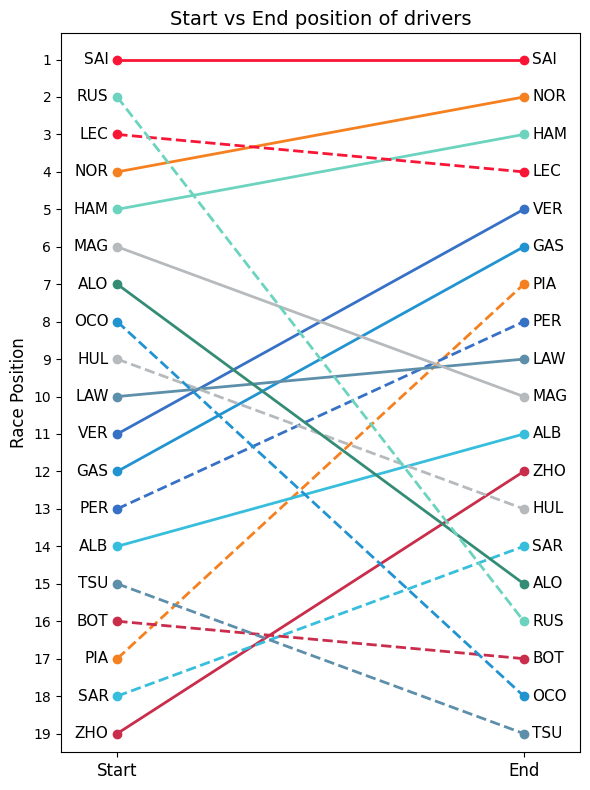

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
data = {
    "Driver": [number_to_acronym[int(d)] for d in drivers],
    "Start": start_positions,
    "End": end_positions
}

df = pd.DataFrame(data)
df = df.sort_values("End")

# Plot setup
plt.figure(figsize=(6, 8), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

x_start = 0.265
x_end = 0.735

# Track how many times a color has been used (per team color)
color_usage = {}

for _, row in df.iterrows():
    driver = row["Driver"]
    color = f"#{driver_color[driver]}"

    # Alternate style if same color has been used before
    if color not in color_usage:
        color_usage[color] = 0
    color_usage[color] += 1

    linestyle = '-' if color_usage[color] == 1 else '--'

    # Draw line
    plt.plot([x_start, x_end], [row["Start"], row["End"]],
             marker='o',
             color=color,
             linewidth=2,
             linestyle=linestyle)

    # Driver labels
    plt.text(x_start - 0.01, row["Start"], driver,
             ha='right', va='center', fontsize=11)
    plt.text(x_end + 0.01, row["End"], driver,
             ha='left', va='center', fontsize=11)

# Y-axis and layout
plt.yticks(range(1, 20))
plt.ylim(19.5, 0.3)

plt.xticks([x_start, x_end], ["Start", "End"], fontsize=12)
plt.xlim(0.2, 0.8)

plt.ylabel("Race Position", fontsize=12)
plt.title("Start vs End position of drivers", fontsize=14)

plt.tight_layout()
plt.show()
